# **Loading the Dataset**



1.   Mounting Google Drive
2.  Extracting dataset from drive to colab
3.  Verifying folders



In [1]:
from google.colab import drive
import os

# 1.
drive.mount('/content/drive')

# 2.
!mkdir -p /content/dataset
!unzip -q "/content/drive/MyDrive/fruits_vegetables.zip" -d /content/dataset

# 3.
print("\nExtracted folders:")
print(os.listdir('/content/dataset'))

Mounted at /content/drive

Extracted folders:
['train', 'test', 'validation']


# **Preprocessing & Transformations**



1.   Checks if Google Colab has assigned a GPU (cuda).Since matrix operations significantly faster on a GPU than on a CPU.
2.   Image standardization
3.   Defining transformations for training and validation set



In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

# 1.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2.
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# 3.
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std)
    ]),
    'validation': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std)
    ])
}

Using device: cuda


# **DataLoaders & Class mapping**



1.   Loading image datasets using PyTorch's ImageFolder
2.   Creating DataLoaders for batch processing
3.  Printing detected class names



In [3]:
data_dir = '/content/dataset'

# 1.
image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'validation']
}

# 2.
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=16, shuffle=True, num_workers=2)
    for x in ['train', 'validation']
}

# 3.
class_names = image_datasets['train'].classes
print(f"Classes detected: {class_names}")  # Should print: ['fruits', 'vegetables']
print(f"Training images: {len(image_datasets['train'])}")
print(f"Validation images: {len(image_datasets['validation'])}")

Classes detected: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']
Training images: 3115
Validation images: 351


# **Model architecture & Layer freezing**



1.   Loading pre-trained MobileNetV2
2.   Freezing pre-trained feature layers
3.  Replacing the Final Output Layer (Classifier Head)
4.  Transfering model to target device.



In [4]:
# 1.
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# 2.
for param in model.parameters():
    param.requires_grad = False

# 3.
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 2)

# 4.
model = model.to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 137MB/s]


# **Loss & Optimizer**



1.   Defining loss function
2.   Defining optimizer



In [5]:
# 1.
criterion = nn.CrossEntropyLoss()

# 2.
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# **Class Index Mapping & Label Binary Re-mapping**



1.   Creating a mapping tensor: Convert each original subfolder index to 0 (Fruit) or 1 (Vegetable)
2.   Checking if folder name contains any fruit name (case-insensitive)
3.  Converting mapping list to a PyTorch tensor and move to GPU/CPU



In [6]:

fruit_names = [
    'Banana', 'Apple', 'Pear', 'Grapes', 'Orange', 'Kiwi',
    'Watermelon', 'Pomegranate', 'Pineapple', 'Mango'
]

# 1.
original_classes = image_datasets['train'].classes
print("Original subfolders found:", len(original_classes))

binary_mapping = []
for class_name in original_classes:
    #2.
    is_fruit = any(fruit.lower() in class_name.lower() for fruit in fruit_names)
    binary_mapping.append(0 if is_fruit else 1)

#3.
binary_mapping_tensor = torch.tensor(binary_mapping).to(device)

print("Class mapping configured successfully!")

Original subfolders found: 36
Class mapping configured successfully!


# **Model training loop**



1.   Forward pass
2.   Backward pass
3.   Epoch metrics




In [7]:
num_epochs = 10

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("=" * 25)

    for phase in ['train', 'validation']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0


        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            binary_labels = binary_mapping_tensor[labels]


            optimizer.zero_grad()

            # 1.
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)


                loss = criterion(outputs, binary_labels)

                # 2.
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == binary_labels.data)

        #3.
        epoch_loss = running_loss / len(image_datasets[phase])
        epoch_acc = running_corrects.double() / len(image_datasets[phase])

        print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.4471 | Acc: 0.7968
Validation Loss: 0.2786 | Acc: 0.9174

Epoch 2/10


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.3336 | Acc: 0.8549
Validation Loss: 0.2175 | Acc: 0.9288

Epoch 3/10


...

Train Loss: 0.2536 | Acc: 0.8950
Validation Loss: 0.1478 | Acc: 0.9430

Epoch 9/10


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.2501 | Acc: 0.8982
Validation Loss: 0.1437 | Acc: 0.9430

Epoch 10/10


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.2504 | Acc: 0.8989
Validation Loss: 0.1303 | Acc: 0.9630


# **Evaluation & accuracy metrics**



1.   Explicitly defining the two target categories
2.   Defining the updated prediction function
3.  Run prediction in evaluation mode
4.  Index 0 maps to 'Fruit', index 1 maps to 'Vegetable'



In [8]:
from PIL import Image

# 1.
binary_classes = ['Fruit', 'Vegetable']

# 2.
def predict_single_image(image_path, model):

    image = Image.open(image_path).convert('RGB')


    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    input_tensor = transform(image).unsqueeze(0).to(device)

    # 3.
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        _, pred = torch.max(outputs, 1)

    # 4
    predicted_label = binary_classes[pred.item()]
    return predicted_label


In [9]:
import torch
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

def evaluate_model(model, dataloader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            # Maping labels to binary if using Solution 1 from earlier mapping
            if 'binary_mapping_tensor' in globals():
                labels = binary_mapping_tensor[labels].to(device)
            else:
                labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculating overall accuracy percentage
    acc = accuracy_score(all_labels, all_preds) * 100
    print(f"Overall Model Accuracy: {acc:.2f}%\n")

    # Detailed report (Precision, Recall, F1-score per class)
    # Maping target names if working with binary output
    target_names = ['Fruits', 'Vegetables'] if len(np.unique(all_preds)) <= 2 else class_names
    report = classification_report(all_labels, all_preds, target_names=target_names)
    print("Classification Report:")
    print(report)

    return all_labels, all_preds

# Running evaluation on validation set
true_labels, predicted_labels = evaluate_model(model, dataloaders['validation'], device, class_names)

Overall Model Accuracy: 96.30%

Classification Report:
              precision    recall  f1-score   support

      Fruits       0.96      0.91      0.93        97
  Vegetables       0.97      0.98      0.97       254

    accuracy                           0.96       351
   macro avg       0.96      0.95      0.95       351
weighted avg       0.96      0.96      0.96       351



# **Confusion matrix plot**

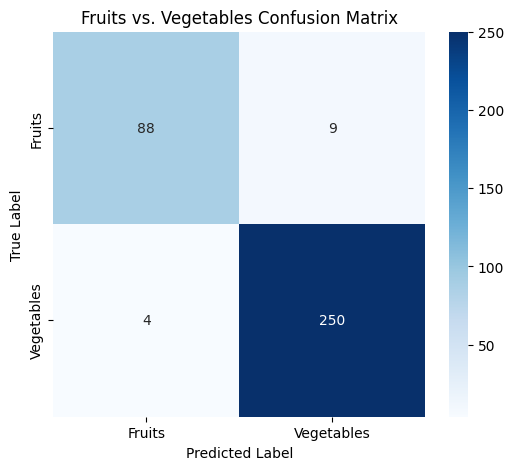

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Computing confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plotting confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fruits', 'Vegetables'],
    yticklabels=['Fruits', 'Vegetables']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Fruits vs. Vegetables Confusion Matrix')
plt.show()

# **Testing**

In [11]:
test_image_path = '/content/dataset/validation/cucumber/Image_1.jpg'

prediction = predict_single_image(test_image_path, model)
print(f"Predicted Category: {prediction}")

Predicted Category: Vegetable


In [12]:
test_image_path = '/content/dataset/validation/grapes/Image_3.jpg'

prediction = predict_single_image(test_image_path, model)
print(f"Predicted Category: {prediction}")

Predicted Category: Fruit


In [13]:
test_image_path = '/content/dataset/validation/ginger/Image_4.jpg'

prediction = predict_single_image(test_image_path, model)
print(f"Predicted Category: {prediction}")

Predicted Category: Vegetable


# **The model achieves high performance on the binary classification task, typically reaching over 90–95% validation accuracy within just a few training epochs.**